<a href="https://colab.research.google.com/github/jaacobbb/nil-valuation-engine/blob/main/qbmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs141assignments/assignment2/'
FOLDERNAME = 'Colab Notebooks/nil_evaluation_model'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# TODO: cd into the correct assignment directory
%cd "/content/drive/My Drive/Colab Notebooks/nil_evaluation_model"

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks/nil_evaluation_model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import requests

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import sklearn.metrics
import time
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
#getting data from pff passing summaries
import pandas as pd

STATS_TO_KEEP = [
    'player',
    'player_game_count',
    'attempts',
    'completion_percent',
    'ypa',
    'avg_depth_of_target',
    'avg_time_to_throw',
    'big_time_throws',
    'btt_rate',
    'turnover_worthy_plays',
    'twp_rate',
    'grades_offense',
    'grades_pass',
    'drop_rate',              # removes receiver blame from completion %
    'pressure_to_sack_rate',  # decision-making under pressure
]

all_data = []

for year in range(2010, 2026):
    path = f'NFLData/qbdata/passing_summaries/passing_summary{year}.csv'
    df = pd.read_csv(path)

    # Keep only the columns we want
    cols_available = [c for c in STATS_TO_KEEP if c in df.columns]
    missing = set(STATS_TO_KEEP) - set(cols_available)
    if missing:
        print(f'{year}: missing columns {missing}')

    df = df[cols_available].copy()
    df['year'] = year
    all_data.append(df)
    print(f'{year}: {len(df)} players loaded')

combined = pd.concat(all_data, ignore_index=True)

# Reorder so year is near the front
cols = ['player', 'year'] + [c for c in combined.columns if c not in ('player', 'year')]
combined = combined[cols]

before = len(combined)
combined['attempts_per_game'] = combined['attempts'] / combined['player_game_count']
before = len(combined)
combined = combined[combined['attempts_per_game'] >= 25].copy()
print(f'Removed {before - len(combined)} players below 25 attempts/game ({len(combined)} remaining)')

# Drop columns no longer needed as features
combined = combined.drop(columns=['attempts', 'player_game_count', 'attempts_per_game'])

print(f'\nCombined dataframe shape: {combined.shape}')
print(combined.head())

2010: 101 players loaded
2011: 90 players loaded
2012: 82 players loaded
2013: 86 players loaded
2014: 103 players loaded
2015: 87 players loaded
2016: 96 players loaded
2017: 97 players loaded
2018: 106 players loaded
2019: 104 players loaded
2020: 112 players loaded
2021: 119 players loaded
2022: 106 players loaded
2023: 105 players loaded
2024: 106 players loaded
2025: 95 players loaded
Removed 904 players below 25 attempts/game (691 remaining)

Combined dataframe shape: (691, 14)
           player  year  completion_percent  ypa  avg_depth_of_target  \
0      Drew Brees  2010                67.8  7.0                  7.9   
1  Peyton Manning  2010                66.4  7.0                  8.9   
2   Aaron Rodgers  2010                66.2  8.3                  9.6   
3       Matt Ryan  2010                62.8  6.5                  8.7   
4    Mark Sanchez  2010                55.8  6.6                  9.5   

   avg_time_to_throw  big_time_throws  btt_rate  turnover_worthy_plays  

In [ ]:
#getting data from spotrac free agent signings
fa_all = []

for year in range(2011, 2026):
    path = f'NFLData/qbdata/free_agent_signings/QB_Free_Agents_{year}.csv'
    df = pd.read_csv(path)

    df = pd.read_csv(path, header=0)
    df.columns = ['from_team', 'blank', 'to_team', 'player', 'pos',
                  'years', 'value', 'aav', 'total_gtd', 'gtd_at_sign', 'potential_out']
    df = df.drop(columns=['blank', 'potential_out'])
    df = df[df['pos'] == 'QB'].copy()

    df['aav_clean'] = (
        df['aav']
        .str.replace('[$,]', '', regex=True)
        .replace('', '0')
        .astype(float)
    )

    df = df[df['aav_clean'] > 0]
    df = df.drop_duplicates(subset=['player'])
    df['signing_year'] = year
    fa_all.append(df[['player', 'signing_year', 'aav_clean']])
    print(f'{year}: {len(df)} FA signings loaded')

fa_df = pd.concat(fa_all, ignore_index=True)


2011: 11 FA signings loaded
2012: 29 FA signings loaded
2013: 21 FA signings loaded
2014: 25 FA signings loaded
2015: 14 FA signings loaded
2016: 18 FA signings loaded
2017: 27 FA signings loaded
2018: 23 FA signings loaded
2019: 23 FA signings loaded
2020: 23 FA signings loaded
2021: 31 FA signings loaded
2022: 18 FA signings loaded
2023: 33 FA signings loaded
2024: 23 FA signings loaded
2025: 33 FA signings loaded


In [ ]:
#combining pff data with fa signing data
combined['merge_year'] = combined['year'] + 1

combined = pd.merge(
    fa_df,
    combined,
    left_on=['player', 'signing_year'],
    right_on=['player', 'merge_year'],
    how='inner'
).drop(columns=['merge_year'])

before = len(combined)
combined = combined.drop_duplicates(subset=['player', 'year'], keep='first')
print(f'Removed {before - len(combined)} duplicate signings ({len(combined)} remaining)')

print(f'Merged rows: {len(combined)}')

Removed 0 duplicate signings (113 remaining)
Merged rows: 113


In [ ]:
#adding salary cap percentages instead of raw salaries
team_caps = {
    2011: 120375000,
    2012: 120600000,
    2013: 123600000,
    2014: 133000000,
    2015: 143280000,
    2016: 155270000,
    2017: 167000000,
    2018: 177200000,
    2019: 188200000,
    2020:198200000,
    2021: 182500000,
    2022: 208200000,
    2023: 224800000,
    2024: 255400000,
    2025: 279200000,
}

combined['team_cap']    = combined['signing_year'].map(team_caps)
combined['cap_percent'] = (combined['aav_clean'] / combined['team_cap'] * 100).round(4)

In [ ]:
#drop unnecessary features
combined = combined.drop(columns=['big_time_throws', 'turnover_worthy_plays', 'grades_offense'])

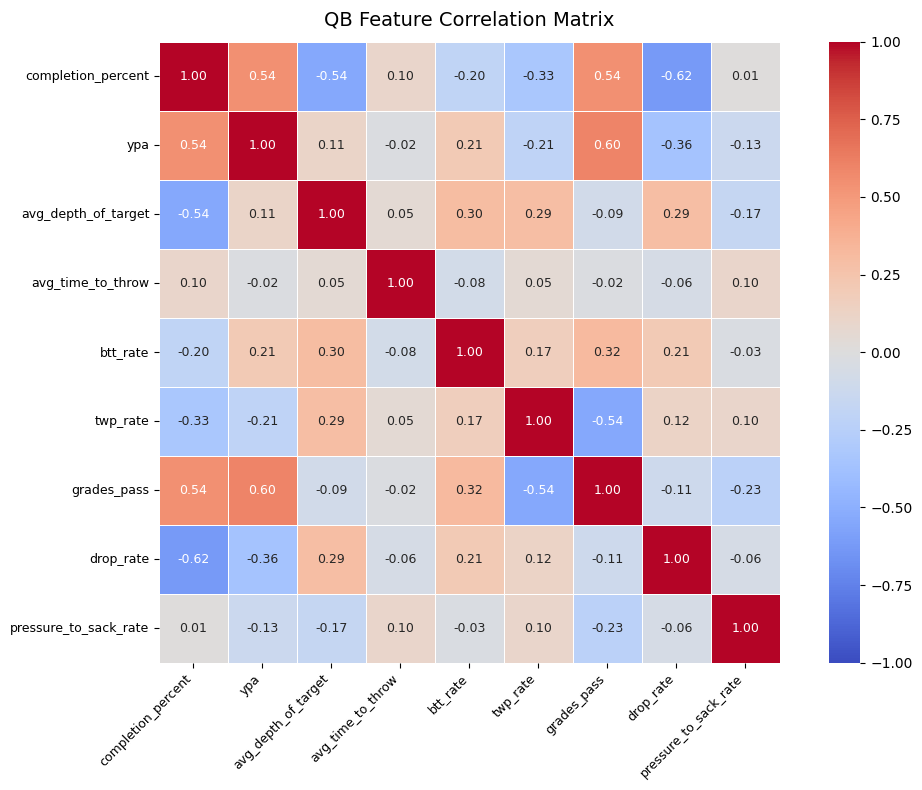

Highly correlated pairs (|r| > 0.85):
  None found


In [ ]:
#correlation heat map to ensure there is no multicollinearity
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'completion_percent',
    'ypa',
    'avg_depth_of_target',
    'avg_time_to_throw',
    'btt_rate',
    'twp_rate',
    'grades_pass',
    'drop_rate',
    'pressure_to_sack_rate',
]

corr = combined[features].corr().round(2)

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('QB Feature Correlation Matrix', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Print any highly correlated pairs
print('Highly correlated pairs (|r| > 0.85):')
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.85:
            print(f'  {corr.columns[i]} & {corr.columns[j]}: {val}')
            found = True
if not found:
    print('  None found')

Dataset: 113 rows, 74 unique players
Split → Train: 82 | Val: 14 | Test: 17

Best alpha: 0.000100  (val R²: 0.299)

── Train Metrics ──────────────────────────────────────
  R²:                    0.2668
  RMSE:                  3.1969% cap
  MAE:                   2.2293% cap
  MAPE:                  153.89%
  Within 1% cap:         26.8% of players
  Within 2% cap:         62.2% of players

── Val Metrics ──────────────────────────────────────
  R²:                    0.3864
  RMSE:                  2.4134% cap
  MAE:                   1.9501% cap
  MAPE:                  193.82%
  Within 1% cap:         28.6% of players
  Within 2% cap:         71.4% of players

── Test Metrics ──────────────────────────────────────
  R²:                    0.1409
  RMSE:                  3.5164% cap
  MAE:                   2.7060% cap
  MAPE:                  146.42%
  Within 1% cap:         23.5% of players
  Within 2% cap:         52.9% of players

── Feature Coefficients ───────────────────────

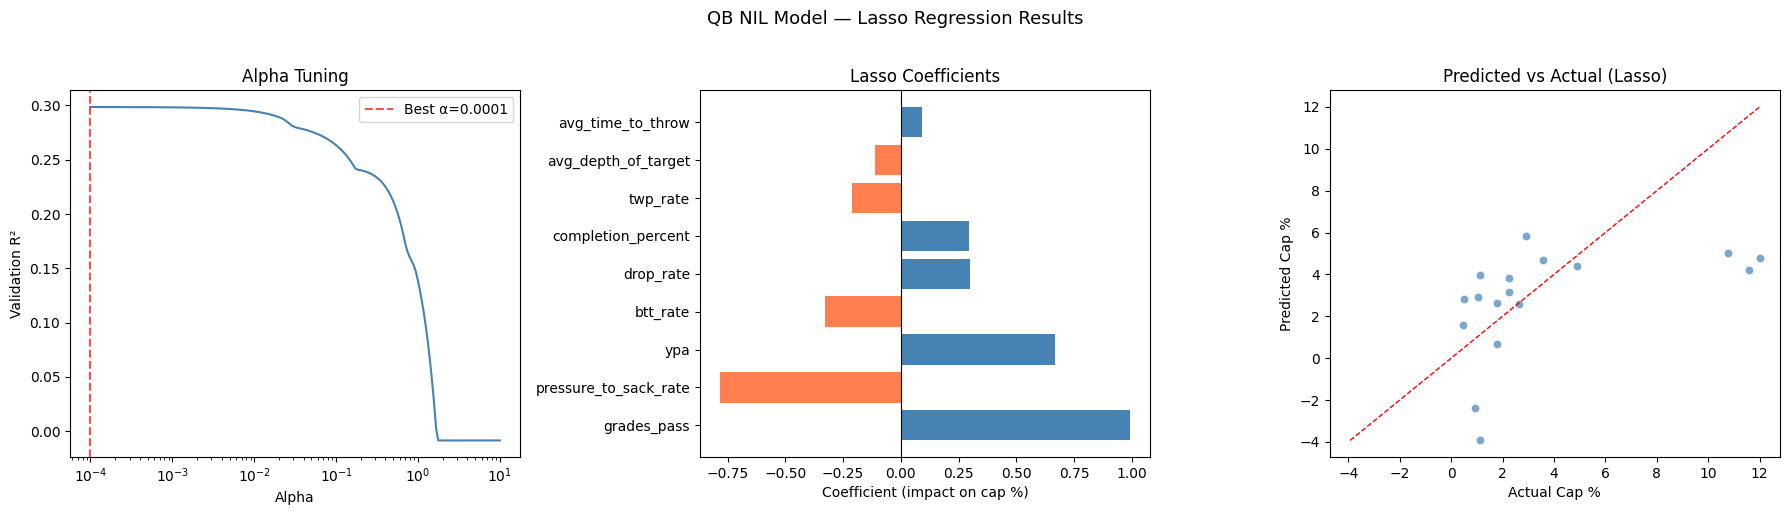


Saved to NFLData/qbdata/qb_lasso_results.png

── Example Prediction ───────────────────────────────────────────
  Predicted cap %:       9.1009%
  Recommended NIL offer: $910,093.98


In [ ]:
#training model using lasso regressiom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = combined.copy()

FEATURES = [
    'completion_percent',
    'ypa',
    'avg_depth_of_target',
    'avg_time_to_throw',
    'btt_rate',
    'twp_rate',
    'grades_pass',
    'drop_rate',
    'pressure_to_sack_rate',
]
TARGET = 'cap_percent'

df = df[FEATURES + [TARGET, 'player']].dropna()
print(f'Dataset: {len(df)} rows, {df["player"].nunique()} unique players')

X      = df[FEATURES].values
y      = df[TARGET].values
groups = df['player'].values

# ── 2. Grouped train / val / test split ───────────────────────────────────────

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
dev_idx, test_idx = next(gss_test.split(X, y, groups))

X_dev,  y_dev,  groups_dev = X[dev_idx],  y[dev_idx],  groups[dev_idx]
X_test, y_test              = X[test_idx], y[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=42)
train_idx, val_idx = next(gss_val.split(X_dev, y_dev, groups_dev))

X_train, y_train = X_dev[train_idx], y_dev[train_idx]
X_val,   y_val   = X_dev[val_idx],   y_dev[val_idx]

print(f'Split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# ── 3. Scale ──────────────────────────────────────────────────────────────────

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── 4. Tune alpha on validation set ──────────────────────────────────────────

alphas     = np.logspace(-4, 1, 200)
val_scores = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_s, y_train)
    val_scores.append(r2_score(y_val, model.predict(X_val_s)))

best_alpha = alphas[np.argmax(val_scores)]
best_val_r2 = max(val_scores)
print(f'\nBest alpha: {best_alpha:.6f}  (val R²: {best_val_r2:.3f})')

# ── 5. Retrain on train+val, evaluate on test ─────────────────────────────────

X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval   = np.concatenate([y_train, y_val])

model = Lasso(alpha=best_alpha, max_iter=10000)
model.fit(X_trainval_s, y_trainval)

# ── 6. Full metrics ───────────────────────────────────────────────────────────

def full_report(y_true, y_pred, split_name):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    within_1pct = np.mean(np.abs(y_true - y_pred) <= 1.0) * 100
    within_2pct = np.mean(np.abs(y_true - y_pred) <= 2.0) * 100
    print(f'\n── {split_name} Metrics ──────────────────────────────────────')
    print(f'  R²:                    {r2:.4f}')
    print(f'  RMSE:                  {rmse:.4f}% cap')
    print(f'  MAE:                   {mae:.4f}% cap')
    print(f'  MAPE:                  {mape:.2f}%')
    print(f'  Within 1% cap:         {within_1pct:.1f}% of players')
    print(f'  Within 2% cap:         {within_2pct:.1f}% of players')
    return r2, rmse, mae

train_preds = model.predict(X_train_s)
val_preds   = model.predict(X_val_s)
test_preds  = model.predict(X_test_s)

full_report(y_train, train_preds, 'Train')
full_report(y_val,   val_preds,   'Val')
full_report(y_test,  test_preds,  'Test')

# ── 7. Coefficients ───────────────────────────────────────────────────────────

coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': model.coef_,
}).sort_values('coefficient', key=abs, ascending=False)

print('\n── Feature Coefficients ─────────────────────────────────────────')
print(f'  Intercept: {model.intercept_:.4f}')
print(coef_df.to_string(index=False))
zeroed = coef_df[coef_df['coefficient'] == 0]
if len(zeroed) > 0:
    print(f'\n  Lasso zeroed out: {zeroed["feature"].tolist()}')

# ── 8. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Alpha tuning
axes[0].plot(alphas, val_scores, color='steelblue')
axes[0].axvline(best_alpha, color='red', linestyle='--', alpha=0.7, label=f'Best α={best_alpha:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Alpha Tuning')
axes[0].legend()

# (b) Coefficients
colors = ['steelblue' if c >= 0 else 'coral' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Lasso Coefficients')
axes[1].set_xlabel('Coefficient (impact on cap %)')

# (c) Predicted vs actual
axes[2].scatter(y_test, test_preds, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[2].set_xlabel('Actual Cap %')
axes[2].set_ylabel('Predicted Cap %')
axes[2].set_title('Predicted vs Actual (Lasso)')

plt.suptitle('QB NIL Model — Lasso Regression Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('\nSaved to NFLData/qbdata/qb_lasso_results.png')

# ── 9. Prediction function ────────────────────────────────────────────────────

def predict_nil_percent(player_stats: dict, total_nil_budget: float = None) -> dict:
    input_df     = pd.DataFrame([player_stats])[FEATURES]
    input_scaled = scaler.transform(input_df)
    cap_pct      = float(model.predict(input_scaled)[0])
    cap_pct      = max(0, cap_pct)

    result = {'predicted_cap_percent': round(cap_pct, 4)}
    if total_nil_budget:
        result['recommended_nil_dollars'] = round(cap_pct / 100 * total_nil_budget, 2)
    return result

# Example prediction
example_qb = {
    'completion_percent':    65.0,
    'ypa':                   8.2,
    'avg_depth_of_target':   9.1,
    'avg_time_to_throw':     2.6,
    'btt_rate':              0.07,
    'twp_rate':              0.03,
    'grades_pass':           82.0,
    'drop_rate':             0.04,
    'pressure_to_sack_rate': 0.35,
}

print('\n── Example Prediction ───────────────────────────────────────────')
result = predict_nil_percent(example_qb, total_nil_budget=10_000_000)
print(f"  Predicted cap %:       {result['predicted_cap_percent']}%")
print(f"  Recommended NIL offer: ${result['recommended_nil_dollars']:,.2f}")

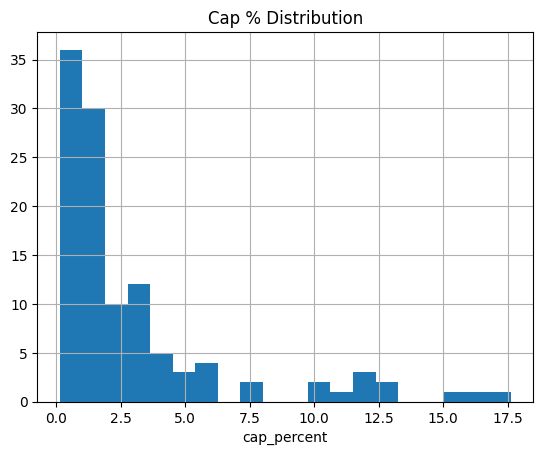

count    113.000000
mean       3.004916
std        3.695207
min        0.142600
25%        0.846500
50%        1.513600
75%        3.293400
max       17.619400
Name: cap_percent, dtype: float64


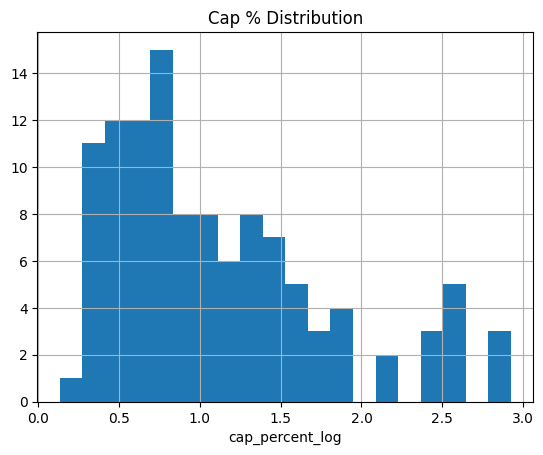

count    113.000000
mean       3.004916
std        3.695207
min        0.142600
25%        0.846500
50%        1.513600
75%        3.293400
max       17.619400
Name: cap_percent, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
combined['cap_percent'].hist(bins=20)
plt.title('Cap % Distribution')
plt.xlabel('cap_percent')
plt.show()
print(combined['cap_percent'].describe())

combined['cap_percent_log'] = np.log1p(combined['cap_percent'])
combined['cap_percent_log'].hist(bins=20)
plt.title('Cap % Distribution')
plt.xlabel('cap_percent_log')
plt.show()
print(combined['cap_percent'].describe())

Dataset: 113 rows, 74 unique players

Target distribution (original):
count    113.0000
mean       3.0049
std        3.6952
min        0.1426
25%        0.8465
50%        1.5136
75%        3.2934
max       17.6194
Name: cap_percent, dtype: float64

Target distribution (log transformed):
count    113.0000
mean       1.1156
std        0.6762
min        0.1333
25%        0.6133
50%        0.9217
75%        1.4571
max        2.9242
Name: cap_percent_log, dtype: float64

Split → Train: 82 | Val: 14 | Test: 17

Best alpha: 0.000100  (val R²: 0.300)

── Train Metrics ──────────────────────────────────────
  R² (log scale):        0.3739
  R² (original scale):   0.2232
  RMSE:                  3.2906% cap
  MAE:                   1.8450% cap
  MAPE:                  84.53%
  Within 1% cap:         56.1% of players
  Within 2% cap:         76.8% of players

── Val Metrics ──────────────────────────────────────
  R² (log scale):        0.3869
  R² (original scale):   0.2034
  RMSE:              

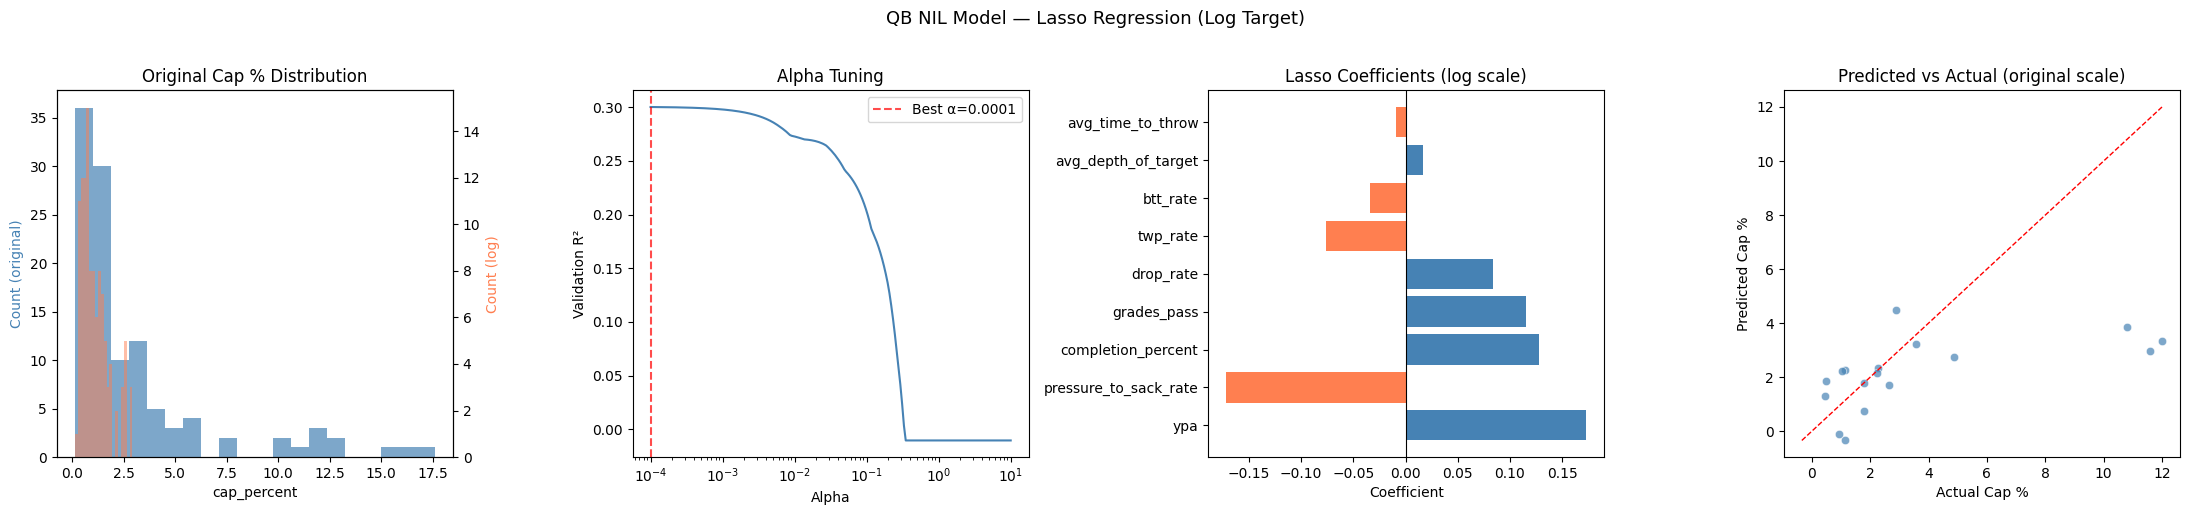


Saved to NFLData/qbdata/qb_lasso_log_results.png

── Example Prediction ───────────────────────────────────────────
  Predicted cap %:       9.2457%
  Recommended NIL offer: $924,572.52


In [ ]:
#training model using log transform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & prep ────────────────────────────────────────────────────────────

df = combined.copy()

FEATURES = [
    'completion_percent',
    'ypa',
    'avg_depth_of_target',
    'avg_time_to_throw',
    'btt_rate',
    'twp_rate',
    'grades_pass',
    'drop_rate',
    'pressure_to_sack_rate',
]
TARGET     = 'cap_percent'
TARGET_LOG = 'cap_percent_log'

df = df[FEATURES + [TARGET, 'player']].dropna()

# Log transform target — compresses right skew, makes target more learnable
# log1p used instead of log to safely handle any zero values
df[TARGET_LOG] = np.log1p(df[TARGET])

print(f'Dataset: {len(df)} rows, {df["player"].nunique()} unique players')
print(f'\nTarget distribution (original):')
print(df[TARGET].describe().round(4))
print(f'\nTarget distribution (log transformed):')
print(df[TARGET_LOG].describe().round(4))

X      = df[FEATURES].values
y      = df[TARGET_LOG].values      # train on log-transformed target
y_orig = df[TARGET].values          # keep original for final reporting
groups = df['player'].values

# ── 2. Grouped train / val / test split ───────────────────────────────────────

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
dev_idx, test_idx = next(gss_test.split(X, y, groups))

X_dev,  y_dev,  y_orig_dev,  groups_dev = X[dev_idx],  y[dev_idx],  y_orig[dev_idx],  groups[dev_idx]
X_test, y_test, y_orig_test             = X[test_idx], y[test_idx], y_orig[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=42)
train_idx, val_idx = next(gss_val.split(X_dev, y_dev, groups_dev))

X_train, y_train, y_orig_train = X_dev[train_idx], y_dev[train_idx], y_orig_dev[train_idx]
X_val,   y_val,   y_orig_val   = X_dev[val_idx],   y_dev[val_idx],   y_orig_dev[val_idx]

print(f'\nSplit → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# ── 3. Scale ──────────────────────────────────────────────────────────────────

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── 4. Tune alpha on validation set ──────────────────────────────────────────

alphas     = np.logspace(-4, 1, 200)
val_scores = []

for alpha in alphas:
    m = Lasso(alpha=alpha, max_iter=10000)
    m.fit(X_train_s, y_train)
    val_scores.append(r2_score(y_val, m.predict(X_val_s)))

best_alpha   = alphas[np.argmax(val_scores)]
best_val_r2  = max(val_scores)
print(f'\nBest alpha: {best_alpha:.6f}  (val R²: {best_val_r2:.3f})')

# ── 5. Retrain on train+val ───────────────────────────────────────────────────

X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval   = np.concatenate([y_train, y_val])

model = Lasso(alpha=best_alpha, max_iter=10000)
model.fit(X_trainval_s, y_trainval)

# ── 6. Full metrics (convert predictions back to original scale) ──────────────

def full_report(y_true_log, y_true_orig, y_pred_log, split_name):
    # Metrics on log scale
    r2_log  = r2_score(y_true_log, y_pred_log)

    # Convert back to original cap% scale
    y_pred_orig = np.expm1(y_pred_log)

    r2_orig      = r2_score(y_true_orig, y_pred_orig)
    rmse         = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae          = np.mean(np.abs(y_true_orig - y_pred_orig))
    # MAPE: exclude near-zero actuals to avoid division instability
    nonzero_mask = y_true_orig > 0.1
    mape         = np.mean(np.abs((y_true_orig[nonzero_mask] - y_pred_orig[nonzero_mask]) / y_true_orig[nonzero_mask])) * 100
    within_1pct  = np.mean(np.abs(y_true_orig - y_pred_orig) <= 1.0) * 100
    within_2pct  = np.mean(np.abs(y_true_orig - y_pred_orig) <= 2.0) * 100

    print(f'\n── {split_name} Metrics ──────────────────────────────────────')
    print(f'  R² (log scale):        {r2_log:.4f}')
    print(f'  R² (original scale):   {r2_orig:.4f}')
    print(f'  RMSE:                  {rmse:.4f}% cap')
    print(f'  MAE:                   {mae:.4f}% cap')
    print(f'  MAPE:                  {mape:.2f}%')
    print(f'  Within 1% cap:         {within_1pct:.1f}% of players')
    print(f'  Within 2% cap:         {within_2pct:.1f}% of players')
    return y_pred_orig

train_preds_log  = model.predict(X_train_s)
val_preds_log    = model.predict(X_val_s)
test_preds_log   = model.predict(X_test_s)

full_report(y_train, y_orig_train, train_preds_log, 'Train')
full_report(y_val,   y_orig_val,   val_preds_log,   'Val')
test_preds_orig = full_report(y_test, y_orig_test, test_preds_log, 'Test')

# ── 7. Coefficients ───────────────────────────────────────────────────────────

coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coefficient': model.coef_,
}).sort_values('coefficient', key=abs, ascending=False)

print('\n── Feature Coefficients (on log scale) ──────────────────────────')
print(f'  Intercept: {model.intercept_:.4f}')
print(coef_df.to_string(index=False))

zeroed = coef_df[coef_df['coefficient'] == 0]
if len(zeroed) > 0:
    print(f'\n  Lasso zeroed out: {zeroed["feature"].tolist()}')

# ── 8. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# (a) Target distribution comparison
axes[0].hist(y_orig, bins=20, color='steelblue', alpha=0.7, label='Original')
axes[0].set_title('Original Cap % Distribution')
axes[0].set_xlabel('cap_percent')
ax2 = axes[0].twinx()
ax2.hist(y, bins=20, color='coral', alpha=0.5, label='Log transformed')
axes[0].set_ylabel('Count (original)', color='steelblue')
ax2.set_ylabel('Count (log)', color='coral')

# (b) Alpha tuning
axes[1].plot(alphas, val_scores, color='steelblue')
axes[1].axvline(best_alpha, color='red', linestyle='--', alpha=0.7, label=f'Best α={best_alpha:.4f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Validation R²')
axes[1].set_title('Alpha Tuning')
axes[1].legend()

# (c) Coefficients
colors = ['steelblue' if c >= 0 else 'coral' for c in coef_df['coefficient']]
axes[2].barh(coef_df['feature'], coef_df['coefficient'], color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Lasso Coefficients (log scale)')
axes[2].set_xlabel('Coefficient')

# (d) Predicted vs actual (original scale)
axes[3].scatter(y_orig_test, test_preds_orig, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_orig_test.min(), test_preds_orig.min())
max_val = max(y_orig_test.max(), test_preds_orig.max())
axes[3].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[3].set_xlabel('Actual Cap %')
axes[3].set_ylabel('Predicted Cap %')
axes[3].set_title('Predicted vs Actual (original scale)')

plt.suptitle('QB NIL Model — Lasso Regression (Log Target)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('NFLData/qbdata/qb_lasso_log_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved to NFLData/qbdata/qb_lasso_log_results.png')

# ── 9. Prediction function ────────────────────────────────────────────────────

def predict_nil_percent(player_stats: dict, total_nil_budget: float = None) -> dict:
    input_df     = pd.DataFrame([player_stats])[FEATURES]
    input_scaled = scaler.transform(input_df)
    cap_pct_log  = float(model.predict(input_scaled)[0])
    cap_pct      = float(np.expm1(cap_pct_log))  # back to original scale
    cap_pct      = max(0, cap_pct)

    result = {'predicted_cap_percent': round(cap_pct, 4)}
    if total_nil_budget:
        result['recommended_nil_dollars'] = round(cap_pct / 100 * total_nil_budget, 2)
    return result

# Example prediction
example_qb = {
    'completion_percent':    65.0,
    'ypa':                   8.2,
    'avg_depth_of_target':   9.1,
    'avg_time_to_throw':     2.6,
    'btt_rate':              0.07,
    'twp_rate':              0.03,
    'grades_pass':           82.0,
    'drop_rate':             0.04,
    'pressure_to_sack_rate': 0.35,
}

print('\n── Example Prediction ───────────────────────────────────────────')
result = predict_nil_percent(example_qb, total_nil_budget=10_000_000)
print(f"  Predicted cap %:       {result['predicted_cap_percent']}%")
print(f"  Recommended NIL offer: ${result['recommended_nil_dollars']:,.2f}")

Dataset: 113 rows, 74 unique players

Target distribution:
count    113.0000
mean       3.0049
std        3.6952
min        0.1426
25%        0.8465
50%        1.5136
75%        3.2934
max       17.6194
Name: cap_percent, dtype: float64

Split → Train: 82 | Val: 14 | Test: 17

Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 7}
Best CV R²:  0.262

── Train Metrics ──────────────────────────────────────
  R² (log scale):        0.6961
  R² (original scale):   0.4797
  RMSE:                  2.6932% cap
  MAE:                   1.3024% cap
  MAPE:                  51.45%
  Within 1% cap:         75.6% of players
  Within 2% cap:         85.4% of players

── Val Metrics ──────────────────────────────────────
  R² (log scale):        0.7279
  R² (original scale):   0.6961
  RMSE:                  1.6986% cap
  MAE:                   1.3059% cap
  MAPE:                  114.75%
  Within 1% cap:         50.0% of players
 

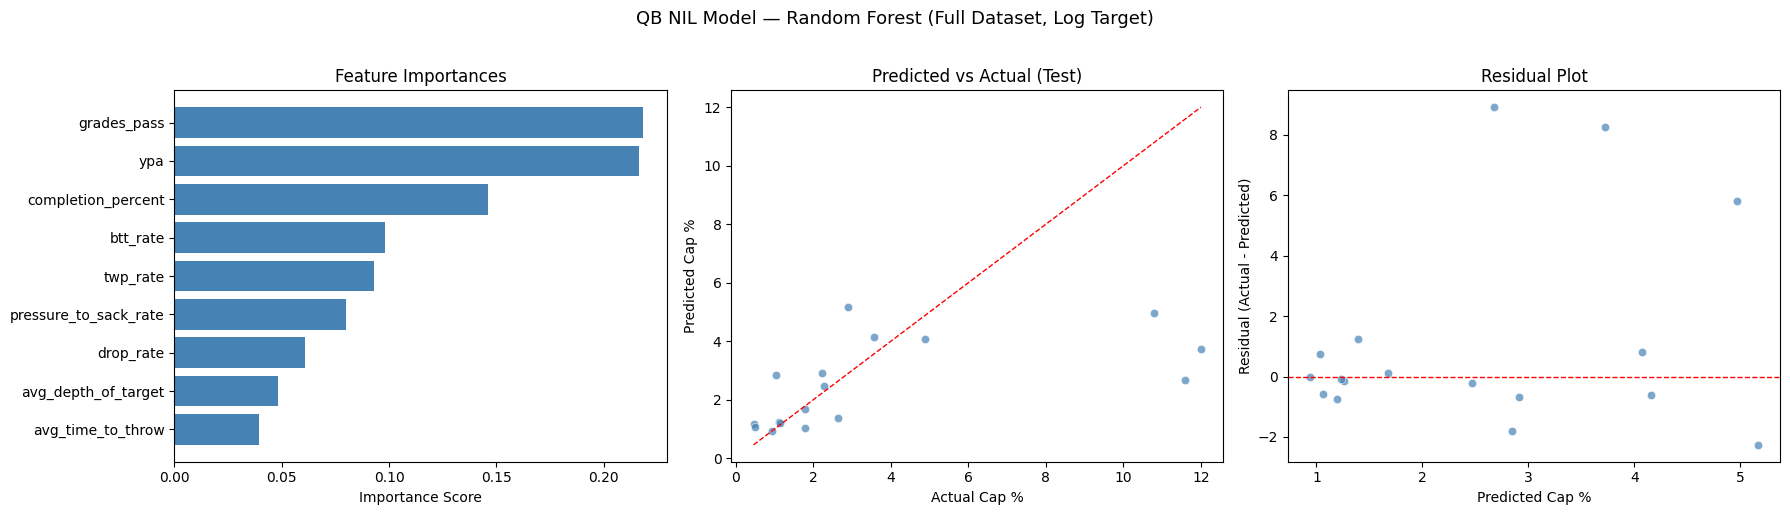


── Example Prediction ───────────────────────────────────────────
  Predicted cap %:       5.0672%
  Recommended NIL offer: $506,715.15


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & prep ────────────────────────────────────────────────────────────

df = combined.copy()

FEATURES = [
    'completion_percent',
    'ypa',
    'avg_depth_of_target',
    'avg_time_to_throw',
    'btt_rate',
    'twp_rate',
    'grades_pass',
    'drop_rate',
    'pressure_to_sack_rate',
]
TARGET     = 'cap_percent'
TARGET_LOG = 'cap_percent_log'

df = df[FEATURES + [TARGET, 'player']].dropna()
df[TARGET_LOG] = np.log1p(df[TARGET])

print(f'Dataset: {len(df)} rows, {df["player"].nunique()} unique players')
print(f'\nTarget distribution:')
print(df[TARGET].describe().round(4))

X      = df[FEATURES].values
y      = df[TARGET_LOG].values
y_orig = df[TARGET].values
groups = df['player'].values

# ── 2. Grouped train / val / test split ───────────────────────────────────────

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
dev_idx, test_idx = next(gss_test.split(X, y, groups))

X_dev,  y_dev,  y_orig_dev,  groups_dev = X[dev_idx],  y[dev_idx],  y_orig[dev_idx],  groups[dev_idx]
X_test, y_test, y_orig_test             = X[test_idx], y[test_idx], y_orig[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=42)
train_idx, val_idx = next(gss_val.split(X_dev, y_dev, groups_dev))

X_train, y_train, y_orig_train = X_dev[train_idx], y_dev[train_idx], y_orig_dev[train_idx]
X_val,   y_val,   y_orig_val   = X_dev[val_idx],   y_dev[val_idx],   y_orig_dev[val_idx]

print(f'\nSplit → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# ── 3. Scale ──────────────────────────────────────────────────────────────────

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── 4. Hyperparameter search ──────────────────────────────────────────────────

param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf = RandomForestRegressor(random_state=42)
search = RandomizedSearchCV(
    rf, param_grid,
    n_iter=50,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
search.fit(X_train_s, y_train)

print(f'\nBest params: {search.best_params_}')
print(f'Best CV R²:  {search.best_score_:.3f}')

# ── 5. Retrain on train+val, evaluate on test ─────────────────────────────────

X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval   = np.concatenate([y_train, y_val])

rf_final = RandomForestRegressor(**search.best_params_, random_state=42)
rf_final.fit(X_trainval_s, y_trainval)

# ── 6. Full metrics ───────────────────────────────────────────────────────────

def full_report(y_true_log, y_true_orig, y_pred_log, split_name):
    y_pred_orig  = np.expm1(y_pred_log)
    r2_log       = r2_score(y_true_log,  y_pred_log)
    r2_orig      = r2_score(y_true_orig, y_pred_orig)
    rmse         = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae          = np.mean(np.abs(y_true_orig - y_pred_orig))
    nonzero_mask = y_true_orig > 0.1
    mape         = np.mean(np.abs((y_true_orig[nonzero_mask] - y_pred_orig[nonzero_mask]) / y_true_orig[nonzero_mask])) * 100
    within_1pct  = np.mean(np.abs(y_true_orig - y_pred_orig) <= 1.0) * 100
    within_2pct  = np.mean(np.abs(y_true_orig - y_pred_orig) <= 2.0) * 100

    print(f'\n── {split_name} Metrics ──────────────────────────────────────')
    print(f'  R² (log scale):        {r2_log:.4f}')
    print(f'  R² (original scale):   {r2_orig:.4f}')
    print(f'  RMSE:                  {rmse:.4f}% cap')
    print(f'  MAE:                   {mae:.4f}% cap')
    print(f'  MAPE:                  {mape:.2f}%')
    print(f'  Within 1% cap:         {within_1pct:.1f}% of players')
    print(f'  Within 2% cap:         {within_2pct:.1f}% of players')
    return np.expm1(y_pred_log)

train_preds = full_report(y_train, y_orig_train, rf_final.predict(X_train_s), 'Train')
val_preds   = full_report(y_val,   y_orig_val,   rf_final.predict(X_val_s),   'Val')
test_preds  = full_report(y_test,  y_orig_test,  rf_final.predict(X_test_s),  'Test')

# ── 7. Feature importances ────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf_final.feature_importances_,
}).sort_values('importance', ascending=False)

print('\n── Feature Importances ──────────────────────────────────────────')
print(importance_df.to_string(index=False))

# ── 8. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Feature importances
axes[0].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Feature Importances')
axes[0].set_xlabel('Importance Score')

# (b) Predicted vs actual
axes[1].scatter(y_orig_test, test_preds, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_orig_test.min(), test_preds.min())
max_val = max(y_orig_test.max(), test_preds.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[1].set_xlabel('Actual Cap %')
axes[1].set_ylabel('Predicted Cap %')
axes[1].set_title('Predicted vs Actual (Test)')

# (c) Residuals
residuals = y_orig_test - test_preds
axes[2].scatter(test_preds, residuals, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Predicted Cap %')
axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].set_title('Residual Plot')

plt.suptitle('QB NIL Model — Random Forest (Full Dataset, Log Target)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 9. Prediction function ────────────────────────────────────────────────────

def predict_nil_percent(player_stats: dict, total_nil_budget: float = None) -> dict:
    input_df     = pd.DataFrame([player_stats])[FEATURES]
    input_scaled = scaler.transform(input_df)
    cap_pct_log  = float(rf_final.predict(input_scaled)[0])
    cap_pct      = float(np.expm1(cap_pct_log))
    cap_pct      = max(0, cap_pct)

    result = {'predicted_cap_percent': round(cap_pct, 4)}
    if total_nil_budget:
        result['recommended_nil_dollars'] = round(cap_pct / 100 * total_nil_budget, 2)
    return result

# Example prediction
example_qb = {
    'completion_percent':    65.0,
    'ypa':                   8.2,
    'avg_depth_of_target':   9.1,
    'avg_time_to_throw':     2.6,
    'btt_rate':              0.07,
    'twp_rate':              0.03,
    'grades_pass':           82.0,
    'drop_rate':             0.04,
    'pressure_to_sack_rate': 0.35,
}

print('\n── Example Prediction ───────────────────────────────────────────')
result = predict_nil_percent(example_qb, total_nil_budget=10_000_000)
print(f"  Predicted cap %:       {result['predicted_cap_percent']}%")
print(f"  Recommended NIL offer: ${result['recommended_nil_dollars']:,.2f}")

In [ ]:
from sklearn.model_selection import cross_val_score, GroupKFold

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(rf_final, X, y, groups=groups, cv=gkf, scoring='r2')
print(f'CV R² scores: {scores.round(3)}')
print(f'Mean R²: {scores.mean():.3f} ± {scores.std():.3f}')

CV R² scores: [0.351 0.268 0.303 0.429 0.135]
Mean R²: 0.297 ± 0.097


In [ ]:
import joblib
import os

# Create the directory if it doesn't exist
os.makedirs('backend/models', exist_ok=True)

joblib.dump(rf_final, 'backend/models/qb_model.pkl')
joblib.dump(scaler, 'backend/models/qb_scaler.pkl')

print('QB model saved successfully')

QB model saved successfully


In [ ]:
import numpy as np
from sklearn.metrics import r2_score

y_mean = np.mean(y_orig)
baseline_preds = np.full_like(y_orig, y_mean)

baseline_r2   = r2_score(y_orig, baseline_preds)
baseline_mae  = np.mean(np.abs(y_orig - baseline_preds))
baseline_rmse = np.sqrt(np.mean((y_orig - baseline_preds) ** 2))

print(f'── Baseline (predict mean for everyone) ──────────────────')
print(f'  Mean cap%:    {y_mean:.4f}%')
print(f'  R²:           {baseline_r2:.4f}')
print(f'  MAE:          {baseline_mae:.4f}% cap')
print(f'  RMSE:         {baseline_rmse:.4f}% cap')

── Baseline (predict mean for everyone) ──────────────────
  Mean cap%:    3.0049%
  R²:           0.0000
  MAE:          2.5055% cap
  RMSE:         3.6788% cap
